# 01. Exploratory Data Analysis (EDA)
## AI Resume–Job Description Semantic Matching System

This notebook inspects the raw dataset `michaelozon/candidate-matching-synthetic`, explores role and seniority distributions, analyzes skill occurrences, and computes text length distributions.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_raw_dataset, inspect_dataset_schema
from src.preprocessing import calculate_text_statistics

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


### 1. Load Raw Resumes Dataset


In [2]:
df = load_raw_dataset()
print('Dataframe shape:', df.shape)
df.head()


[2026-09-06 11:34:12] [INFO] data_loader: Loading raw resumes from local cache: C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\data\raw\raw_resumes.csv


Dataframe shape: (10000, 9)


,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


### 2. Dataset Schema & Missing Values Analysis


In [3]:
schema = inspect_dataset_schema(df)
print('Schema Summary:')
for k, v in schema.items():
    print(f'{k}: {v}')

print('\nMissing values check:')
print(df.isnull().sum())


Schema Summary:
num_rows: 10000
num_columns: 9
columns: ['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']
dtypes: {'resume_id': 'object', 'role': 'object', 'seniority': 'object', 'years_experience': 'int64', 'industry': 'object', 'education': 'object', 'skills': 'object', 'summary': 'object', 'experience_bullets': 'object'}
missing_values: {'resume_id': 0, 'role': 0, 'seniority': 0, 'years_experience': 0, 'industry': 0, 'education': 0, 'skills': 0, 'summary': 0, 'experience_bullets': 0}
unique_roles_count: 24
unique_seniorities: {'Junior': 3372, 'Mid': 3365, 'Senior': 3263}
unique_industries: {'Retail': 1084, 'E-commerce': 1018, 'Gaming': 1018, 'SaaS': 1014, 'Logistics': 1012, 'Travel': 992, 'Cybersecurity': 968, 'EdTech': 967, 'Healthcare': 964, 'FinTech': 963}

Missing values check:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education  

### 3. Role, Seniority, and Industry Distributions


C:\Users\hp\AppData\Local\Temp\ipykernel_16860\3141744832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='role', order=df['role'].value_counts().index[:12], ax=axes[0], palette='viridis')
C:\Users\hp\AppData\Local\Temp\ipykernel_16860\3141744832.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='seniority', order=['Junior', 'Mid', 'Senior'], ax=axes[1], palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_16860\3141744832.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='industry', order=d

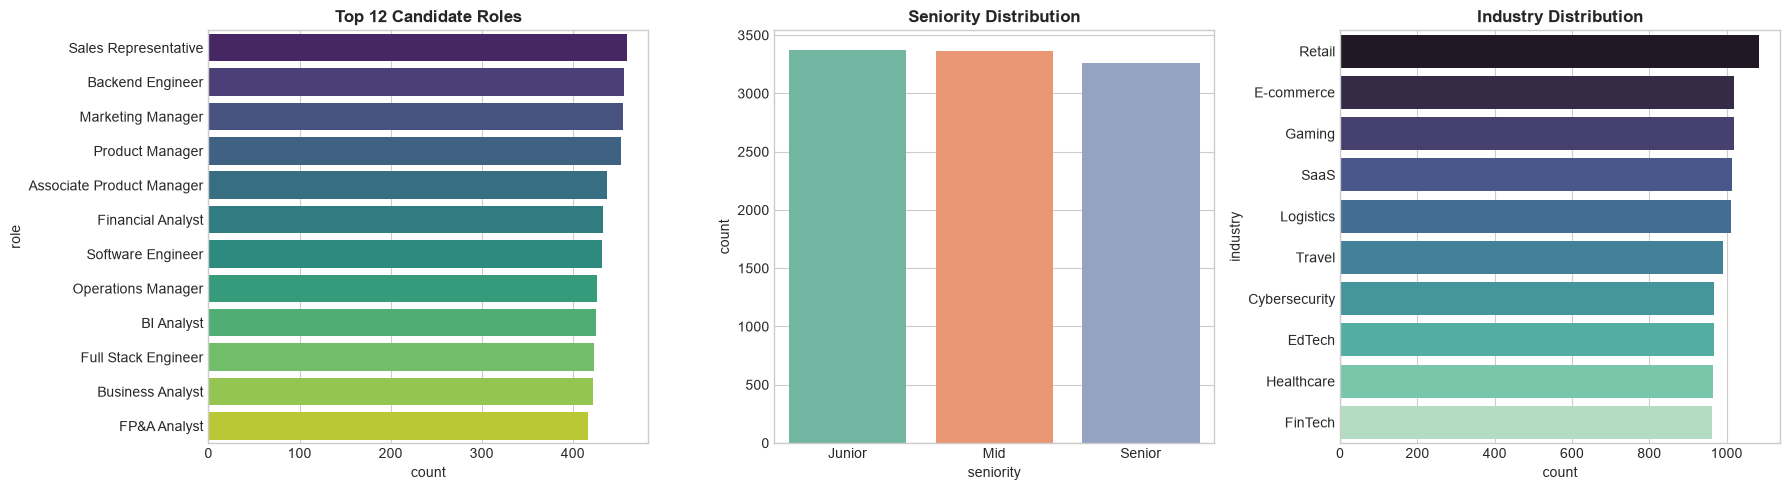

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, y='role', order=df['role'].value_counts().index[:12], ax=axes[0], palette='viridis')
axes[0].set_title('Top 12 Candidate Roles', fontsize=12, fontweight='bold')

sns.countplot(data=df, x='seniority', order=['Junior', 'Mid', 'Senior'], ax=axes[1], palette='Set2')
axes[1].set_title('Seniority Distribution', fontsize=12, fontweight='bold')

sns.countplot(data=df, y='industry', order=df['industry'].value_counts().index, ax=axes[2], palette='mako')
axes[2].set_title('Industry Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 4. Technical Skill Frequency Analysis


C:\Users\hp\AppData\Local\Temp\ipykernel_16860\3439501082.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills_df, x='Count', y='Skill', palette='rocket')


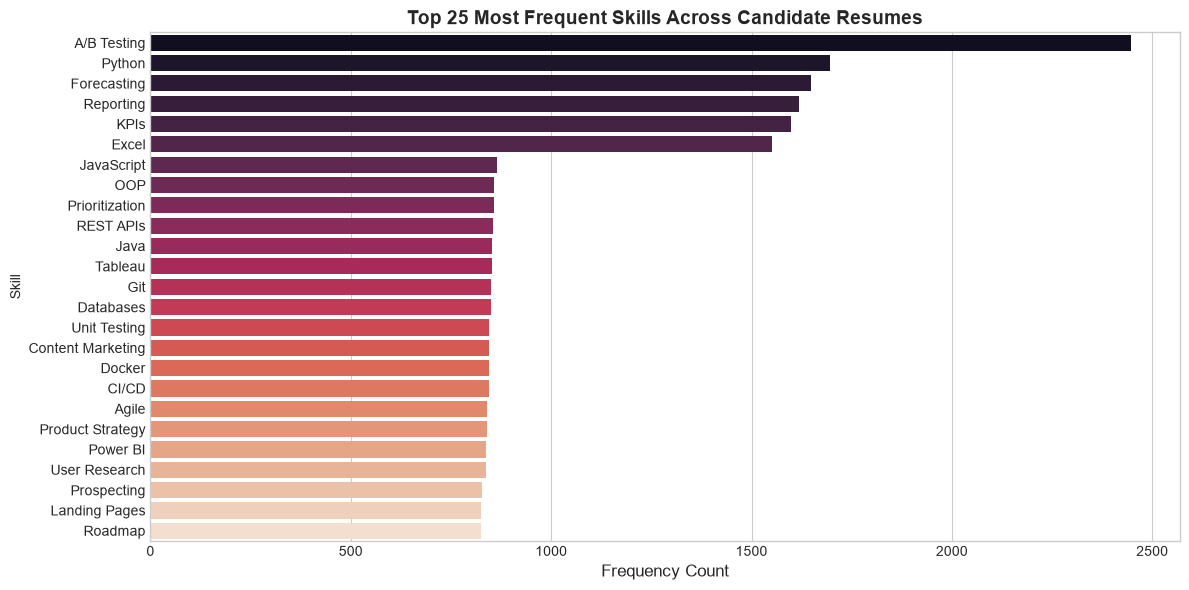

In [5]:
all_skills = [s for sk_list in df['skills'] for s in (sk_list if isinstance(sk_list, list) else [])]
skill_counts = Counter(all_skills)

top_skills_df = pd.DataFrame(skill_counts.most_common(25), columns=['Skill', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_skills_df, x='Count', y='Skill', palette='rocket')
plt.title('Top 25 Most Frequent Skills Across Candidate Resumes', fontsize=14, fontweight='bold')
plt.xlabel('Frequency Count', fontsize=12)
plt.tight_layout()
plt.show()


### 5. Resume Text Length Statistics


Resume Word Count Summary:
count    10000.000000
mean        64.009900
std          2.243414
min         59.000000
25%         62.000000
50%         64.000000
75%         66.000000
max         71.000000
Name: word_count, dtype: float64


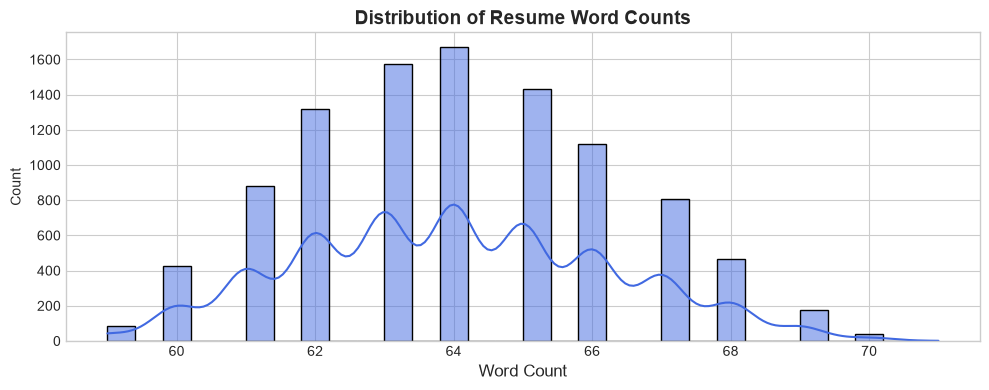

In [6]:
from src.preprocessing import format_resume_text

df['formatted_resume'] = df.apply(format_resume_text, axis=1)
df['char_count'] = df['formatted_resume'].apply(len)
df['word_count'] = df['formatted_resume'].apply(lambda x: len(x.split()))

print('Resume Word Count Summary:')
print(df['word_count'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Resume Word Counts', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12)
plt.tight_layout()
plt.show()
